# U-Net Ablation Study for Scientific Image Forgery Detection

**Key Updates:**
-  **EPOCHS reduced to 20** (faster execution: ~40 minutes per experiment)
-  **Architecture summaries** with parameter counts  
-  **Probability map visualizations** after each training
-  **Output format**: (512, 512, 1) sigmoid probability maps (0=authentic, 1=forged)

**Total Training Time**: ~4-5 hours for 6 experiments on GPU

## 1. Setup and Configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install dependencies
!pip install -q scipy
!pip install -q opencv-python-headless
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q albumentations

In [3]:
import os
import numpy as np
import pandas as pd

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress INFO, WARNING, and ERROR logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN custom operations

import tensorflow as tf

# Set TensorFlow logging level
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras import Model, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from pathlib import Path
import albumentations as A
from glob import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Path to all the relevant folders
DATA_ROOT  = Path("/content/drive/MyDrive/DeepLearning_Project/data/train_images")
DATA_ROOT2 = Path("/content/drive/MyDrive/DeepLearning_Project/data/train_masks")

AUTHENTIC_DIR = Path(DATA_ROOT) / "authentic"
FORGED_DIR    = Path(DATA_ROOT) / "forged"
MASK_DIR      = Path(DATA_ROOT2)

#SPLIT_DIR = Path("/content/drive/MyDrive/DeepLearning_Project/splits")
#TRAIN_CSV = SPLIT_DIR / "train_split.csv"
#VAL_CSV   = SPLIT_DIR / "val_split.csv"

OUTPUT_DIR = Path("/content/drive/MyDrive/DeepLearning_Project/models")

# Training
TARGET_SIZE = (512, 512)
BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 1e-3
MIN_LR = 1e-6
PATIENCE = 10
LR_PATIENCE = 5
SEED = 42

# ImageNet normalization
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 2. Data Loading & Preprocessing

In [5]:


# Find all images and masks
def prepare_dataset():
    """Prepare dataset with paths and labels."""
    data = []

    # Authentic images (no forgery - mask is zeros)
    authentic_dir = AUTHENTIC_DIR
    for img_path in authentic_dir.glob('*.png'):
        data.append({
            'path': str(img_path),
            'label': 'authentic',
            'mask_path': None
        })
    for img_path in authentic_dir.glob('*.jpg'):
        data.append({
            'path': str(img_path),
            'label': 'authentic',
            'mask_path': None
        })

    # Forged images (have masks)
    forged_dir = FORGED_DIR
    mask_dir = MASK_DIR

    for img_path in list(forged_dir.glob('*.png')) + list(forged_dir.glob('*.jpg')):
        stem = img_path.stem
        mask_path = mask_dir / f"{stem}.npy"
        if mask_path.exists():
            data.append({
                'path': str(img_path),
                'label': 'forged',
                'mask_path': str(mask_path)
            })

    df = pd.DataFrame(data)
    print(f"Total samples: {len(df)}")
    print(f"Authentic: {len(df[df['label'] == 'authentic'])}")
    print(f"Forged: {len(df[df['label'] == 'forged'])}")
    return df

df = prepare_dataset()



Total samples: 5128
Authentic: 2377
Forged: 2751


In [6]:
# Train/Val/Test split (70-20-10)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.33, stratify=temp_df['label'], random_state=SEED)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 3589, Val: 1031, Test: 508


In [7]:
# Data augmentation pipelines
def get_augmentation(level='light'):
    h, w = TARGET_SIZE

    if level == 'none':
        return A.Compose([A.Resize(h, w)])

    elif level == 'light':
        return A.Compose([
            A.Resize(h, w),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
        ])

    elif level == 'heavy':
        return A.Compose([
            A.Resize(h, w),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.OneOf([
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
                A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=1.0),
            ], p=0.5),
            A.OneOf([
                A.GaussianBlur(blur_limit=3, p=1.0),
                A.MedianBlur(blur_limit=3, p=1.0),
            ], p=0.2),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, border_mode=0, p=0.3),
        ])

    raise ValueError(f"Unknown augmentation level: {level}")

In [8]:
# Data generator
class SegmentationDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size, target_size, augmentation=None, shuffle=True, crop_strategy='full'):
        """
        crop_strategy options:
        - 'full': Use full image (default)
        - 'forged_tight': Crop tightly to forged region bbox (forged images only)
        - 'forged_context': Crop to forged region + 20% padding (forged images only)
        """
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.crop_strategy = crop_strategy
        self.indexes = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_indexes = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_data = self.df.iloc[batch_indexes]

        images = []
        masks = []

        for _, row in batch_data.iterrows():
            # Load image
            img = tf.keras.preprocessing.image.load_img(row['path'])
            img = np.array(img)

            # Load mask
            if row['mask_path'] and pd.notna(row['mask_path']):
                mask_data = np.load(row['mask_path'])
                if mask_data.ndim == 3:
                    mask = (mask_data.max(axis=0) > 0).astype(np.float32)
                else:
                    mask = (mask_data > 0).astype(np.float32)
            else:
                mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)

            # Apply region cropping (only for forged images)
            if self.crop_strategy != 'full' and mask.sum() > 0:
                # Find bounding box of forged region
                rows = np.any(mask > 0, axis=1)
                cols = np.any(mask > 0, axis=0)
                if rows.sum() > 0 and cols.sum() > 0:
                    y_min, y_max = np.where(rows)[0][[0, -1]]
                    x_min, x_max = np.where(cols)[0][[0, -1]]

                    if self.crop_strategy == 'forged_context':
                        # Add 20% padding
                        h, w = img.shape[:2]
                        pad_y = int((y_max - y_min) * 0.2)
                        pad_x = int((x_max - x_min) * 0.2)
                        y_min = max(0, y_min - pad_y)
                        y_max = min(h, y_max + pad_y)
                        x_min = max(0, x_min - pad_x)
                        x_max = min(w, x_max + pad_x)

                    # Crop image and mask
                    img = img[y_min:y_max+1, x_min:x_max+1]
                    mask = mask[y_min:y_max+1, x_min:x_max+1]

            # Apply augmentation
            if self.augmentation:
                augmented = self.augmentation(image=img, mask=mask)
                img = augmented['image']
                mask = augmented['mask']
            else:
                # Resize
                img = tf.image.resize(img, self.target_size).numpy()
                mask = tf.image.resize(mask[..., np.newaxis], self.target_size, method='nearest').numpy()[..., 0]

            # Normalize image
            img = img.astype(np.float32) / 255.0
            img = (img - MEAN) / STD

            images.append(img)
            masks.append(mask[..., np.newaxis])

        return np.array(images), np.array(masks)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

## 3. Model Architecture - U-Net

In [9]:
def conv_block(x, filters, name=None):
    """Double convolution block with BatchNorm and ReLU."""
    prefix = f"{name}_" if name else ""

    x = layers.Conv2D(filters, 3, padding='same', name=f"{prefix}conv1")(x)
    x = layers.BatchNormalization(name=f"{prefix}bn1")(x)
    x = layers.ReLU(name=f"{prefix}relu1")(x)

    x = layers.Conv2D(filters, 3, padding='same', name=f"{prefix}conv2")(x)
    x = layers.BatchNormalization(name=f"{prefix}bn2")(x)
    x = layers.ReLU(name=f"{prefix}relu2")(x)

    return x

def build_unet_scratch(input_shape=(512, 512, 3), base_filters=32):
    """U-Net from scratch."""
    inputs = layers.Input(shape=input_shape, name='input')

    # Encoder
    c1 = conv_block(inputs, base_filters, 'enc1')
    p1 = layers.MaxPool2D(name='pool1')(c1)

    c2 = conv_block(p1, base_filters * 2, 'enc2')
    p2 = layers.MaxPool2D(name='pool2')(c2)

    c3 = conv_block(p2, base_filters * 4, 'enc3')
    p3 = layers.MaxPool2D(name='pool3')(c3)

    c4 = conv_block(p3, base_filters * 8, 'enc4')
    p4 = layers.MaxPool2D(name='pool4')(c4)

    # Bottleneck
    bn = conv_block(p4, base_filters * 16, 'bottleneck')

    # Decoder
    u4 = layers.UpSampling2D(name='up4')(bn)
    u4 = layers.Concatenate(name='concat4')([u4, c4])
    c5 = conv_block(u4, base_filters * 8, 'dec4')

    u3 = layers.UpSampling2D(name='up3')(c5)
    u3 = layers.Concatenate(name='concat3')([u3, c3])
    c6 = conv_block(u3, base_filters * 4, 'dec3')

    u2 = layers.UpSampling2D(name='up2')(c6)
    u2 = layers.Concatenate(name='concat2')([u2, c2])
    c7 = conv_block(u2, base_filters * 2, 'dec2')

    u1 = layers.UpSampling2D(name='up1')(c7)
    u1 = layers.Concatenate(name='concat1')([u1, c1])
    c8 = conv_block(u1, base_filters, 'dec1')

    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='output')(c8)

    return Model(inputs, outputs, name='UNet_Scratch')

def build_unet_pretrained(input_shape=(512, 512, 3), backbone='resnet50'):
    """U-Net with pretrained encoder."""
    inputs = layers.Input(shape=input_shape, name='input')

    # Pretrained backbone
    if backbone == 'resnet50':
        base_model = tf.keras.applications.ResNet50(
            include_top=False, weights='imagenet', input_tensor=inputs
        )
        skip_names = ['conv1_relu', 'conv2_block3_out', 'conv3_block4_out', 'conv4_block6_out']
    else:
        raise ValueError(f"Unknown backbone: {backbone}")

    # Get skip connections
    skips = [base_model.get_layer(name).output for name in skip_names]
    x = base_model.get_layer('conv5_block3_out').output

    # Decoder
    filters = [256, 128, 64, 32]
    for i, (skip, f) in enumerate(zip(reversed(skips), filters)):
        x = layers.UpSampling2D(size=2, name=f'up_{i}')(x)
        x = layers.Concatenate(name=f'concat_{i}')([x, skip])
        x = conv_block(x, f, f'dec_{i}')

    # Final upsampling to match input size
    x = layers.UpSampling2D(size=2, name='final_up')(x)
    x = conv_block(x, 16, 'final_conv')

    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='output')(x)

    return Model(inputs, outputs, name='UNet_ResNet50')

def visualize_prediction_sample(model, data_gen, title="Model Output Visualization"):
    """Visualize input, ground truth, and predicted probability map."""
    # Get one batch
    images, masks = data_gen[0]

    # Predict
    preds = model.predict(images[:4], verbose=0)  # First 4 samples

    # Plot
    fig, axes = plt.subplots(4, 3, figsize=(12, 15))

    for i in range(min(4, len(images))):
        # Denormalize image for display
        img_display = images[i] * STD + MEAN
        img_display = np.clip(img_display, 0, 1)

        # Input image
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        # Ground truth mask
        axes[i, 1].imshow(masks[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth Mask')
        axes[i, 1].axis('off')

        # Predicted probability map
        axes[i, 2].imshow(preds[i, :, :, 0], cmap='hot', vmin=0, vmax=1)
        axes[i, 2].set_title(f'Probability Map\n(0=authentic, 1=forged)')
        axes[i, 2].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

print("Model architectures and visualization function defined.")

Model architectures and visualization function defined.


In [10]:
# Print model architectures and output shapes
print("=" * 80)
print("U-NET FROM SCRATCH ARCHITECTURE")
print("=" * 80)
model_scratch_demo = build_unet_scratch()
model_scratch_demo.summary()
print(f"\nOutput Shape: {model_scratch_demo.output_shape}")
print(f"Output Activation: sigmoid (values 0.0-1.0)")
print(f"Interpretation: Probability map - 0=authentic, 1=forged region")
print(f"\nTotal Parameters: {model_scratch_demo.count_params():,}")

print("\n" + "=" * 80)
print("U-NET WITH RESNET50 PRETRAINED ARCHITECTURE")
print("=" * 80)
model_pretrained_demo = build_unet_pretrained()
model_pretrained_demo.summary()
print(f"\nOutput Shape: {model_pretrained_demo.output_shape}")
print(f"Total Parameters: {model_pretrained_demo.count_params():,}")

# Clean up demo models
del model_scratch_demo, model_pretrained_demo

U-NET FROM SCRATCH ARCHITECTURE


Model: "UNet_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 512, 512,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 512, 512,  │        896 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 512, 512,  │        128 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1 (ReLU)   │ (None, 512, 512,  │          0 │ enc1_bn1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 512, 512,  │      9,248 │ enc1_relu1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 512, 512,  │        128 │ enc1_conv2[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu2 (ReLU)   │ (None, 512, 512,  │          0 │ enc1_bn2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 256, 256,  │          0 │ enc1_relu2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 256, 256,  │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 256, 256,  │        256 │ enc2_conv1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu1 (ReLU)   │ (None, 256, 256,  │          0 │ enc2_bn1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 256, 256,  │     36,928 │ enc2_relu1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 256, 256,  │        256 │ enc2_conv2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu2 (ReLU)   │ (None, 256, 256,  │          0 │ enc2_bn2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 128, 128,  │          0 │ enc2_relu2[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 128, 128,  │     73,856 │ pool2[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 128, 128,  │        512 │ enc3_conv1[0][0]

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 512, 512,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 518, 518,  │          0 │ input[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 128, 128,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 128, 128,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 128, 128,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 128, 128,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 128, 128,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_3_c

 Total params: 32,603,633 (124.37 MB)

 Trainable params: 32,548,529 (124.16 MB)

 Non-trainable params: 55,104 (215.25 KB)


Output Shape: (None, 512, 512, 1)
Total Parameters: 32,603,633


## 5. Loss Functions

In [11]:
def dice_coef(y_true, y_pred, smooth=1.0):
    """Dice coefficient metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    denom = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    return tf.reduce_mean((2.0 * intersection + smooth) / (denom + smooth))

def iou_coef(y_true, y_pred, smooth=1.0):
    """IoU coefficient metric."""
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1) - intersection

    return tf.reduce_mean((intersection + smooth) / (union + smooth))

def dice_loss(y_true, y_pred):
    """Dice loss."""
    return 1.0 - dice_coef(y_true, y_pred)

def bce_loss(y_true, y_pred):
    """Binary Cross-Entropy loss."""
    return tf.keras.losses.binary_crossentropy(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    """Combined BCE + Dice loss."""
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

def get_loss_function(name):
    """Get loss function by name."""
    losses = {
        'dice': dice_loss,
        'bce': bce_loss,
        'bce_dice': bce_dice_loss
    }
    return losses[name]

## 6. Training Function

In [12]:
def train_experiment(model, train_gen, val_gen, experiment_name, loss_fn, epochs=20):
    """Train a single experiment."""
    print(f"\n{'='*60}")
    print(f"Training: {experiment_name}")
    print(f"{'='*60}")

    # Callbacks
    callbacks = [
        ModelCheckpoint(
            str(OUTPUT_DIR / f'{experiment_name}.keras'),
            monitor='val_dice_coef', mode='max', save_best_only=True, verbose=1
        ),
        EarlyStopping(
            monitor='val_dice_coef', mode='max', patience=PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_dice_coef', mode='max', factor=0.5,
            patience=LR_PATIENCE, min_lr=MIN_LR, verbose=1
        ),
        CSVLogger(str(OUTPUT_DIR / f'{experiment_name}_log.csv'))
    ]

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=loss_fn,
        metrics=[dice_coef, iou_coef]
    )

    # Train
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return history

## 7. Ablation Study 1: Loss Function Comparison

Comparing BCE, Dice, and BCE+Dice loss functions on U-Net scratch model.

In [13]:
# Prepare data generators with light augmentation (baseline)
train_aug = get_augmentation('light')
val_aug = get_augmentation('none')

train_gen = SegmentationDataGenerator(train_df, BATCH_SIZE, TARGET_SIZE, train_aug, shuffle=True)
val_gen = SegmentationDataGenerator(val_df, BATCH_SIZE, TARGET_SIZE, val_aug, shuffle=False)

print(f"Train batches: {len(train_gen)}, Val batches: {len(val_gen)}")

Train batches: 449, Val batches: 129



Training: unet_scratch_bce
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - dice_coef: 0.0316 - iou_coef: 0.3820 - loss: 0.2038
Epoch 1: val_dice_coef improved from -inf to 0.03352, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_bce.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 297s 613ms/step - dice_coef: 0.0316 - iou_coef: 0.3821 - loss: 0.2037 - val_dice_coef: 0.0335 - val_iou_coef: 0.4430 - val_loss: 0.1422 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - dice_coef: 0.0242 - iou_coef: 0.4577 - loss: 0.1256
Epoch 2: val_dice_coef did not improve from 0.03352
449/449 ━━━━━━━━━━━━━━━━━━━━ 260s 580ms/step - dice_coef: 0.0242 - iou_coef: 0.4577 - loss: 0.1256 - val_dice_coef: 0.0313 - val_iou_coef: 0.4638 - val_loss: 0.1456 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - dice_coef: 0.0281 - iou_coef: 0.4682 - loss: 0.1201
Epoch 3: val_dice_coef did not improve from 0.03352
449/449 ━━━━━━━━━━━━━━

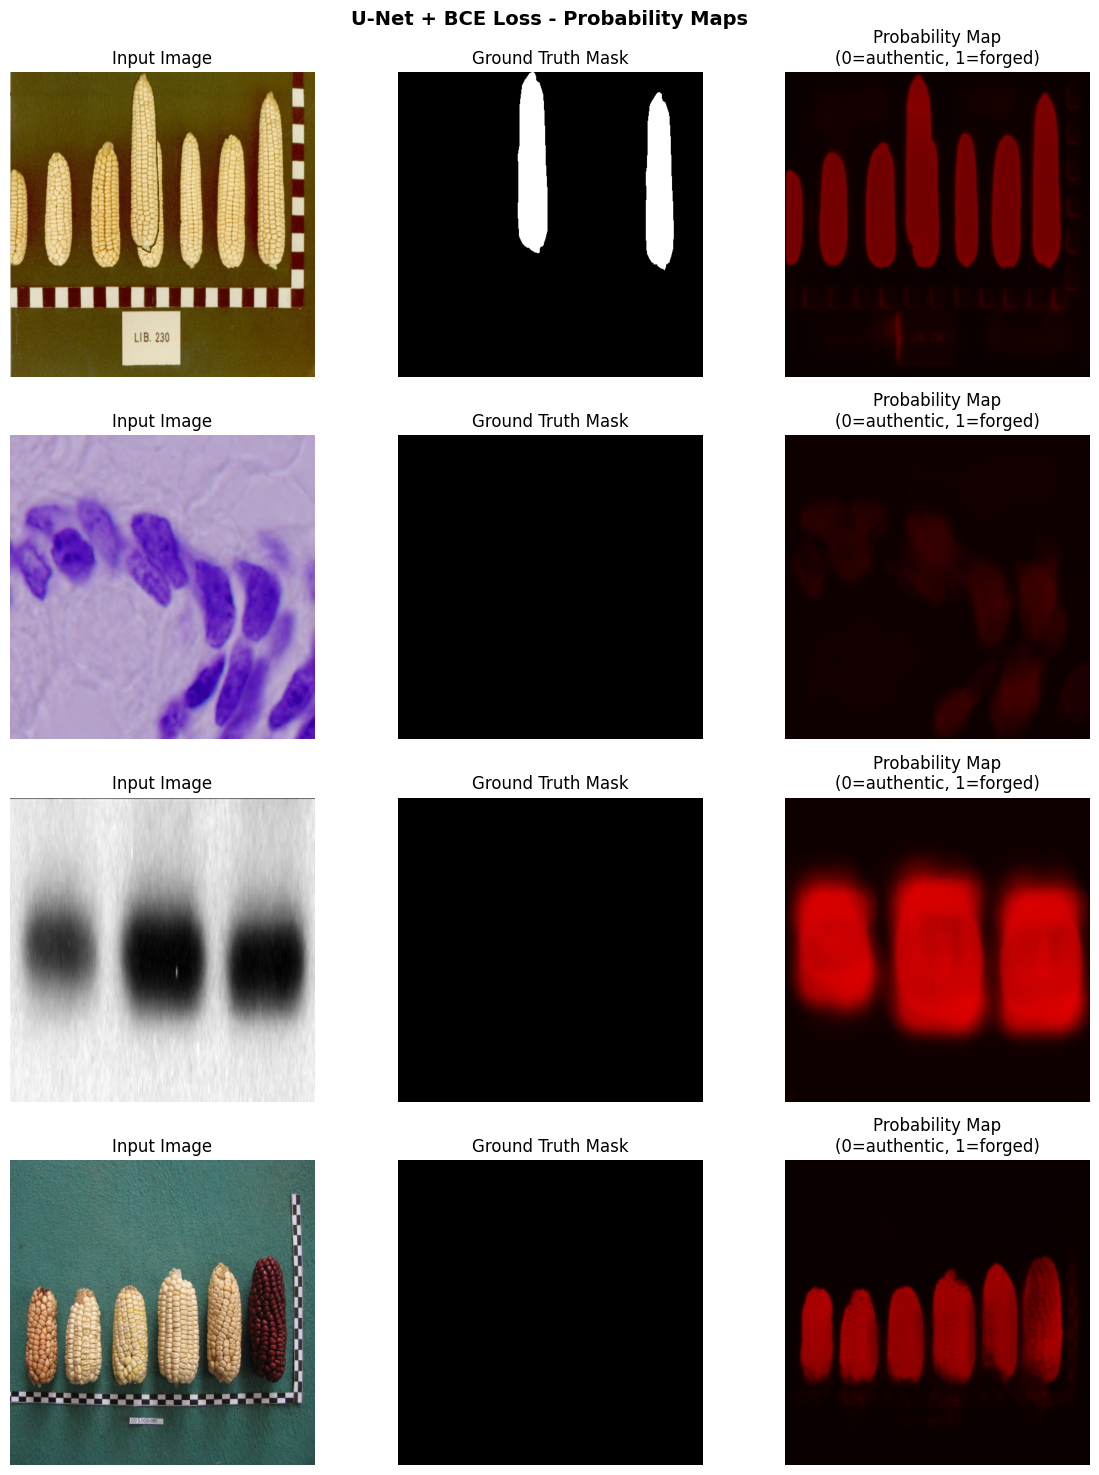

In [19]:
# Ablation 1.1: BCE Loss
model_bce = build_unet_scratch()
history_bce = train_experiment(
    model_bce, train_gen, val_gen,
    'unet_scratch_bce',
    get_loss_function('bce'),
    epochs=EPOCHS
)

# Visualize probability map output
fig = visualize_prediction_sample(model_bce, val_gen, "U-Net + BCE Loss - Probability Maps")
plt.savefig(OUTPUT_DIR / 'unet_bce_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


Training: unet_scratch_dice
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - dice_coef: 0.0771 - iou_coef: 0.0573 - loss: 0.9228
Epoch 1: val_dice_coef improved from -inf to 0.11396, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_dice.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 297s 616ms/step - dice_coef: 0.0771 - iou_coef: 0.0573 - loss: 0.9228 - val_dice_coef: 0.1140 - val_iou_coef: 0.0930 - val_loss: 0.8861 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - dice_coef: 0.1078 - iou_coef: 0.0743 - loss: 0.8922
Epoch 2: val_dice_coef improved from 0.11396 to 0.12396, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_dice.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 266s 592ms/step - dice_coef: 0.1078 - iou_coef: 0.0743 - loss: 0.8922 - val_dice_coef: 0.1240 - val_iou_coef: 0.0875 - val_loss: 0.8761 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - dice_coef: 0.1178 - iou_coef

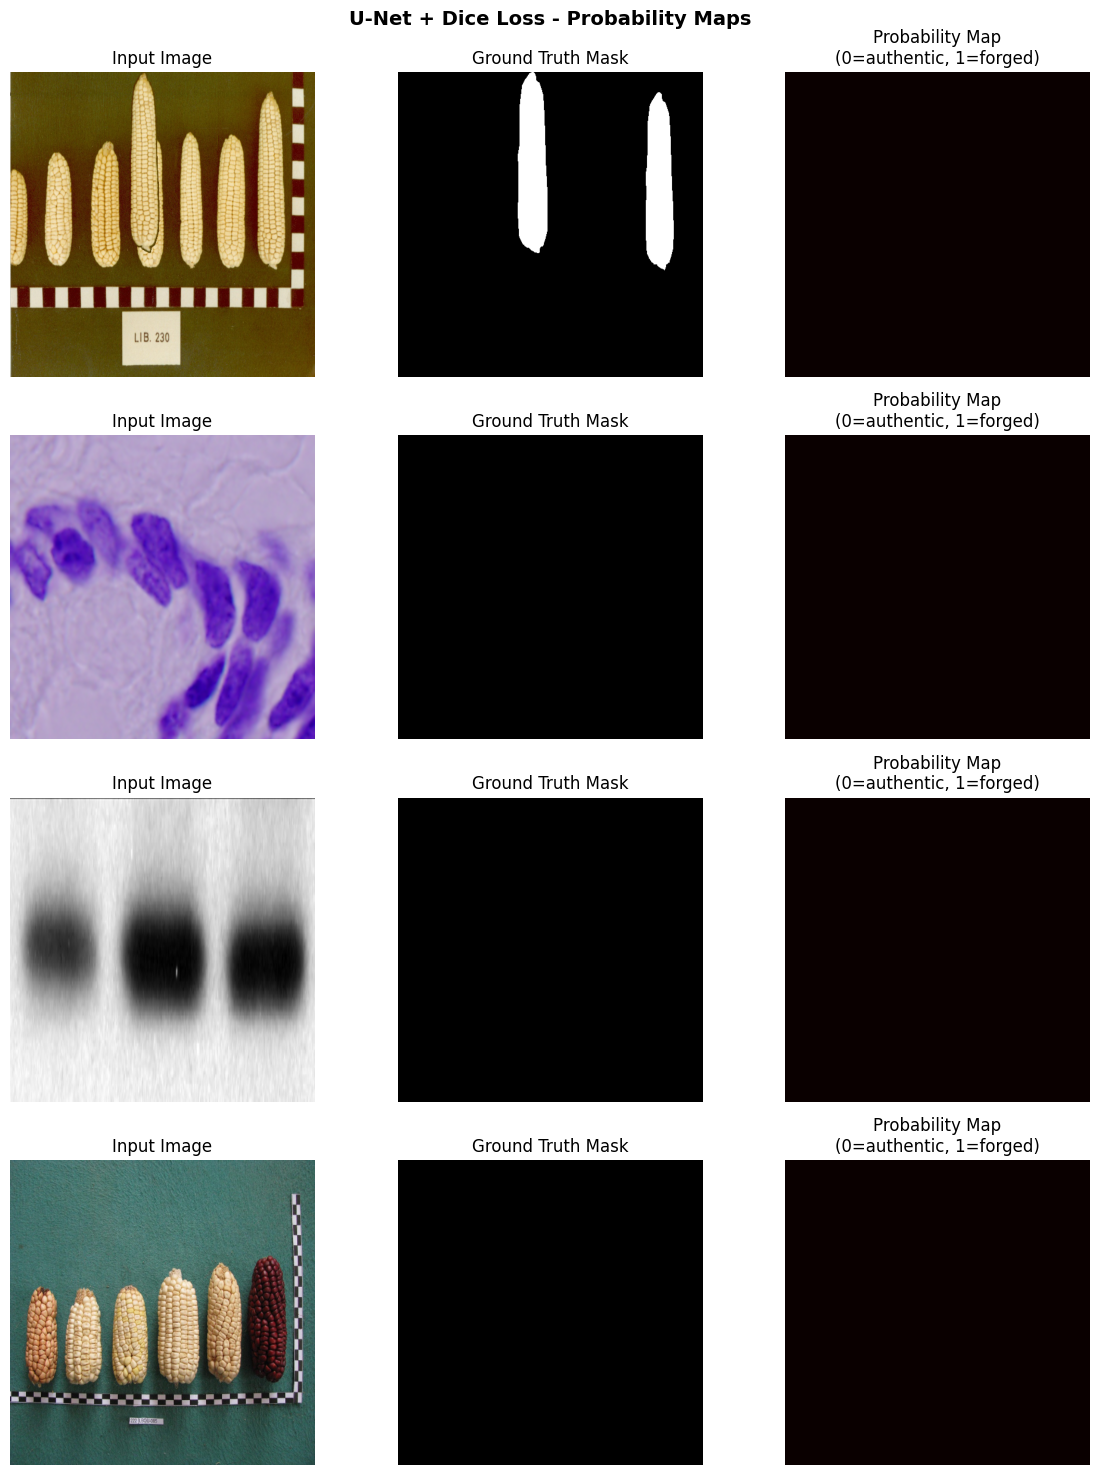

In [ ]:
# Ablation 1.2: Dice Loss
model_dice = build_unet_scratch()
history_dice = train_experiment(
    model_dice, train_gen, val_gen,
    'unet_scratch_dice',
    get_loss_function('dice'),
    epochs=EPOCHS
)

# Visualize probability map output
fig = visualize_prediction_sample(model_dice, val_gen, "U-Net + Dice Loss - Probability Maps")
plt.savefig(OUTPUT_DIR / 'unet_dice_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


Training: unet_scratch_bce_dice
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - dice_coef: 0.0351 - iou_coef: 0.3406 - loss: 1.1882
Epoch 1: val_dice_coef improved from -inf to 0.04453, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_bce_dice.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 297s 616ms/step - dice_coef: 0.0351 - iou_coef: 0.3406 - loss: 1.1881 - val_dice_coef: 0.0445 - val_iou_coef: 0.3847 - val_loss: 1.1154 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - dice_coef: 0.0411 - iou_coef: 0.3784 - loss: 1.0992
Epoch 2: val_dice_coef did not improve from 0.04453
449/449 ━━━━━━━━━━━━━━━━━━━━ 266s 593ms/step - dice_coef: 0.0411 - iou_coef: 0.3784 - loss: 1.0992 - val_dice_coef: 0.0399 - val_iou_coef: 0.3649 - val_loss: 1.1088 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - dice_coef: 0.0564 - iou_coef: 0.2965 - loss: 1.0800
Epoch 3: val_dice_coef improved from 0.04453 to 0.06125, saving 

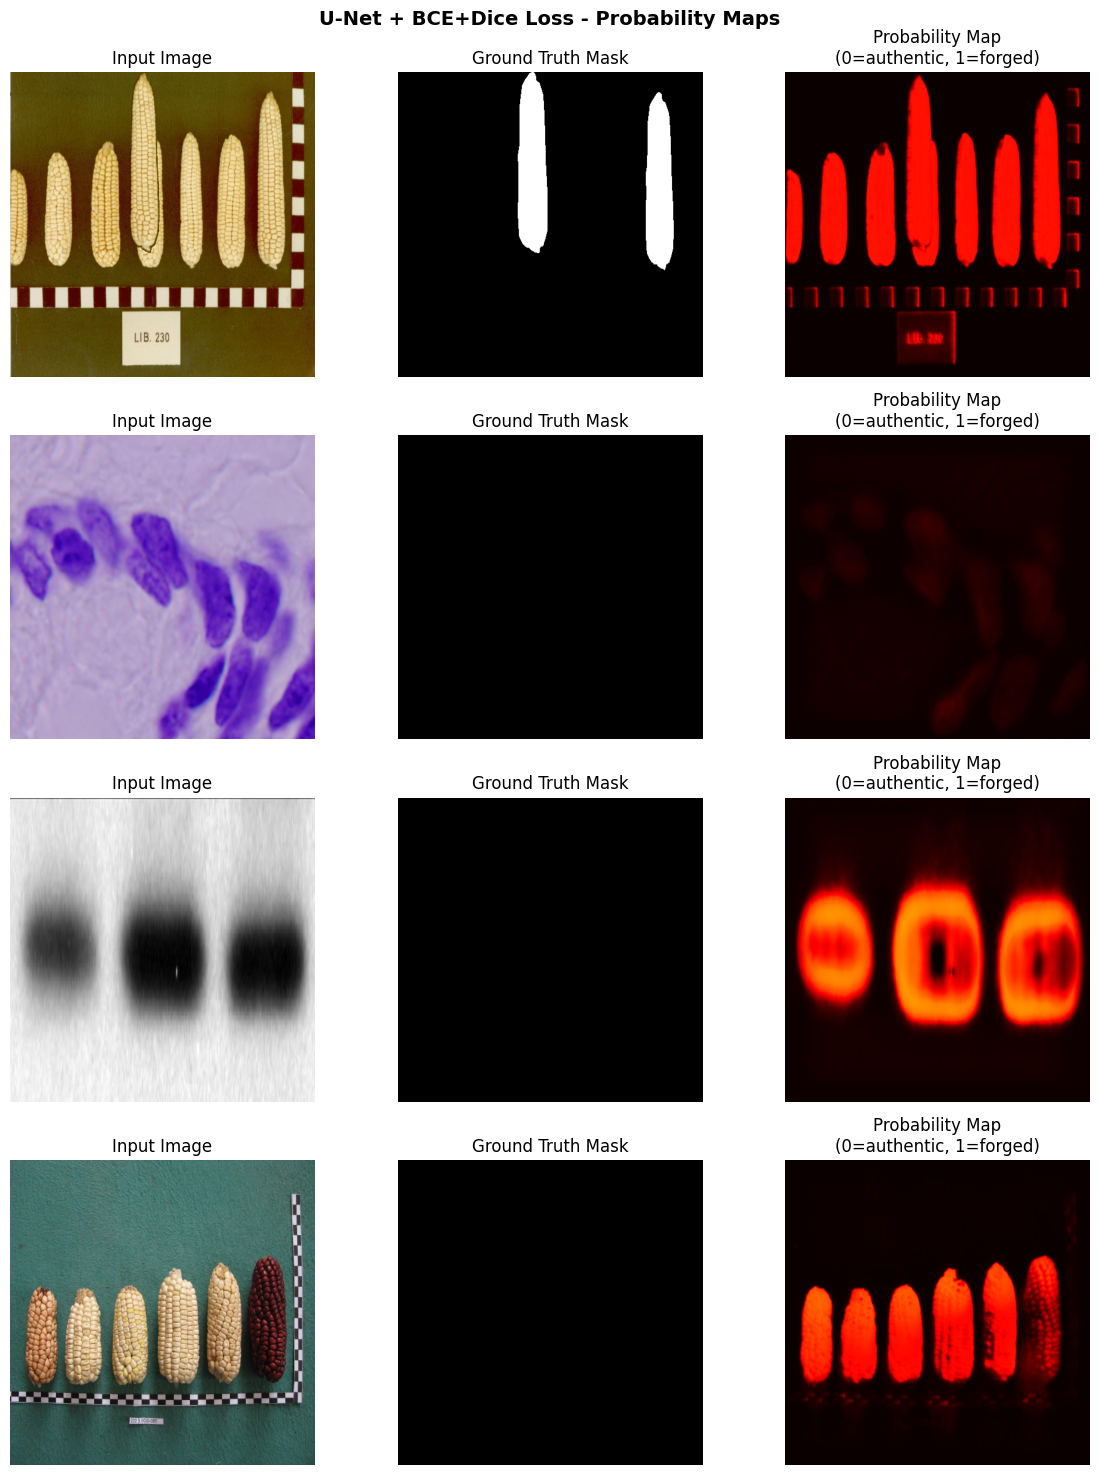

In [ ]:
# Ablation 1.3: BCE + Dice Loss (Baseline)
model_bce_dice = build_unet_scratch()
history_bce_dice = train_experiment(
    model_bce_dice, train_gen, val_gen,
    'unet_scratch_bce_dice',
    get_loss_function('bce_dice'),
    epochs=EPOCHS
)

# Visualize probability map output
fig = visualize_prediction_sample(model_bce_dice, val_gen, "U-Net + BCE+Dice Loss - Probability Maps")
plt.savefig(OUTPUT_DIR / 'unet_bce_dice_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ablation Study 2: Pretrained vs Scratch

Comparing U-Net from scratch vs U-Net with ResNet50 pretrained encoder.

In [ ]:
# Ablation 2.1: U-Net Scratch (already trained as baseline above)
# Using the bce_dice model as baseline
print("U-Net Scratch: Using unet_scratch_bce_dice from Ablation 1")


Training: unet_resnet50_bce_dice
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - dice_coef: 0.0466 - iou_coef: 0.2520 - loss: 1.4003
Epoch 1: val_dice_coef improved from -inf to 0.02712, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_resnet50_bce_dice.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 402s 707ms/step - dice_coef: 0.0466 - iou_coef: 0.2523 - loss: 1.4000 - val_dice_coef: 0.0271 - val_iou_coef: 0.4638 - val_loss: 1.1179 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - dice_coef: 0.0632 - iou_coef: 0.4404 - loss: 1.0795
Epoch 2: val_dice_coef improved from 0.02712 to 0.07119, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_resnet50_bce_dice.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 265s 589ms/step - dice_coef: 0.0632 - iou_coef: 0.4404 - loss: 1.0795 - val_dice_coef: 0.0712 - val_iou_coef: 0.4638 - val_loss: 1.0742 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - dice_coef: 0.

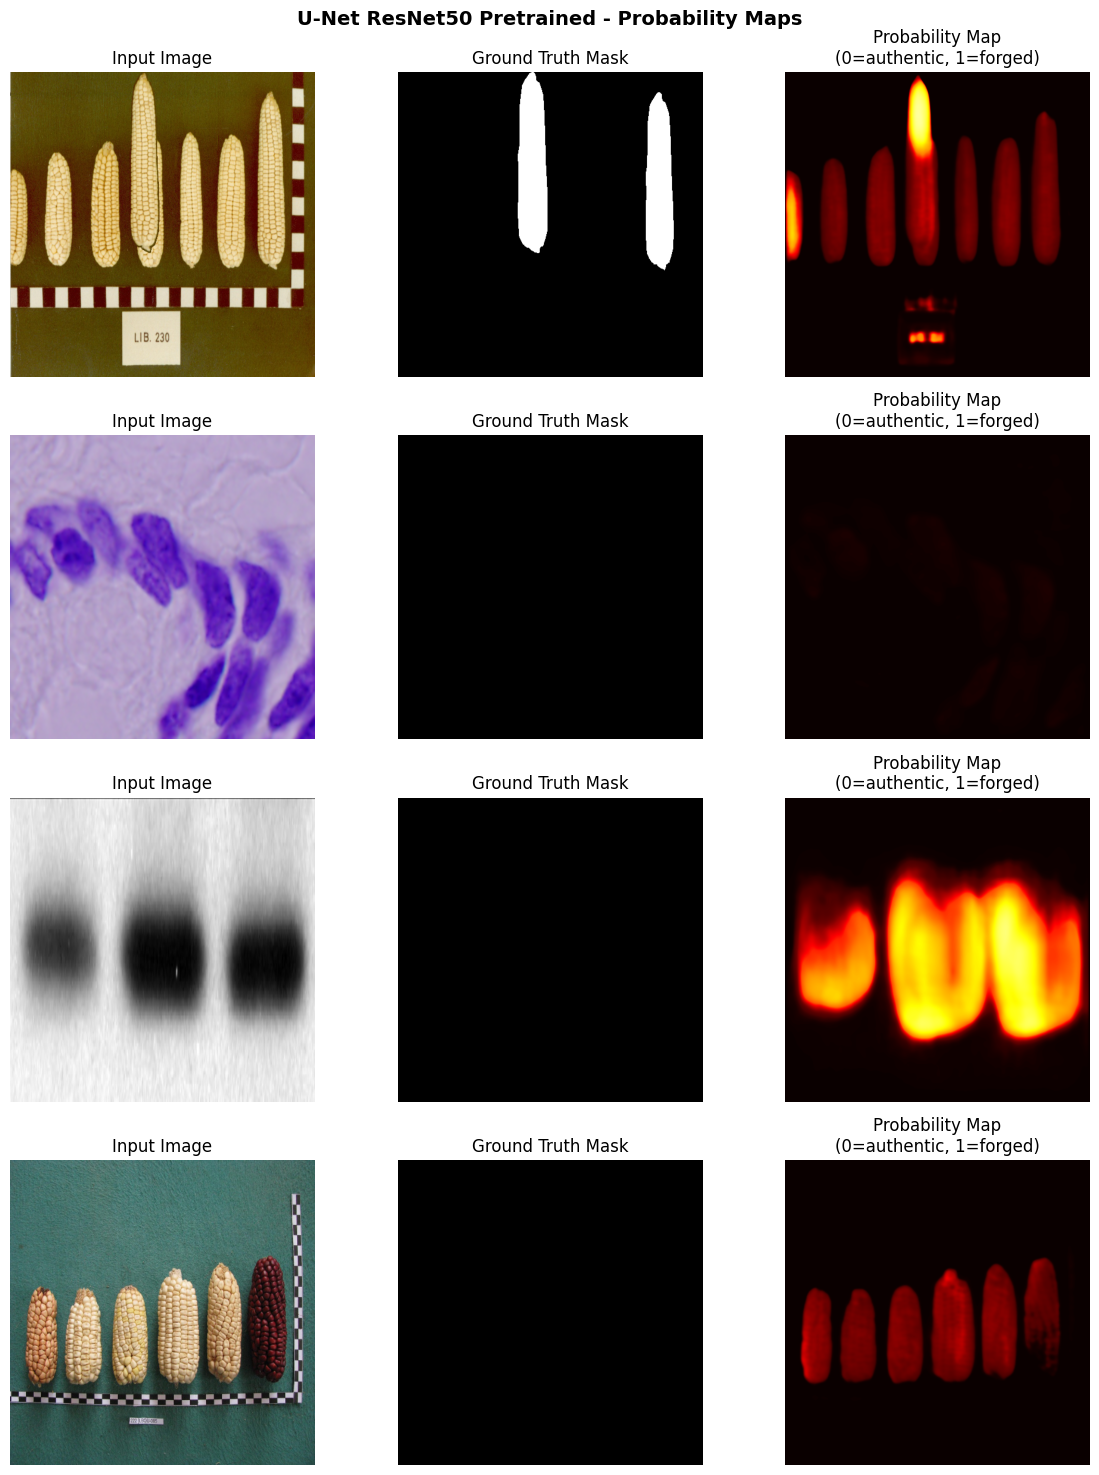

In [ ]:
# Ablation 2.2: U-Net Pretrained (ResNet50)
model_pretrained = build_unet_pretrained(backbone='resnet50')
history_pretrained = train_experiment(
    model_pretrained, train_gen, val_gen,
    'unet_resnet50_bce_dice',
    get_loss_function('bce_dice'),
    epochs=EPOCHS
)

# Visualize probability map output
fig = visualize_prediction_sample(model_pretrained, val_gen, "U-Net ResNet50 Pretrained - Probability Maps")
plt.savefig(OUTPUT_DIR / 'unet_resnet50_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Ablation Study 3: Region-Focused Training

Testing how models perform with different region cropping strategies:
- **Full Image**: Train on complete images (baseline)
- **Forged + Context**: Crop to forged region + 20% padding (more context)
- **Forged Only**: Tight crop to forged region bbox (focused on forgery)


Training: unet_scratch_region_full
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coef: 0.0398 - iou_coef: 0.3638 - loss: 1.1742
Epoch 1: val_dice_coef improved from -inf to 0.04748, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_region_full.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 2502s 5s/step - dice_coef: 0.0398 - iou_coef: 0.3638 - loss: 1.1741 - val_dice_coef: 0.0475 - val_iou_coef: 0.0553 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - dice_coef: 0.0511 - iou_coef: 0.2694 - loss: 1.0907
Epoch 2: val_dice_coef improved from 0.04748 to 0.07872, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_region_full.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 259s 578ms/step - dice_coef: 0.0511 - iou_coef: 0.2693 - loss: 1.0907 - val_dice_coef: 0.0787 - val_iou_coef: 0.0992 - val_loss: 1.2333 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - dice_coef: 0

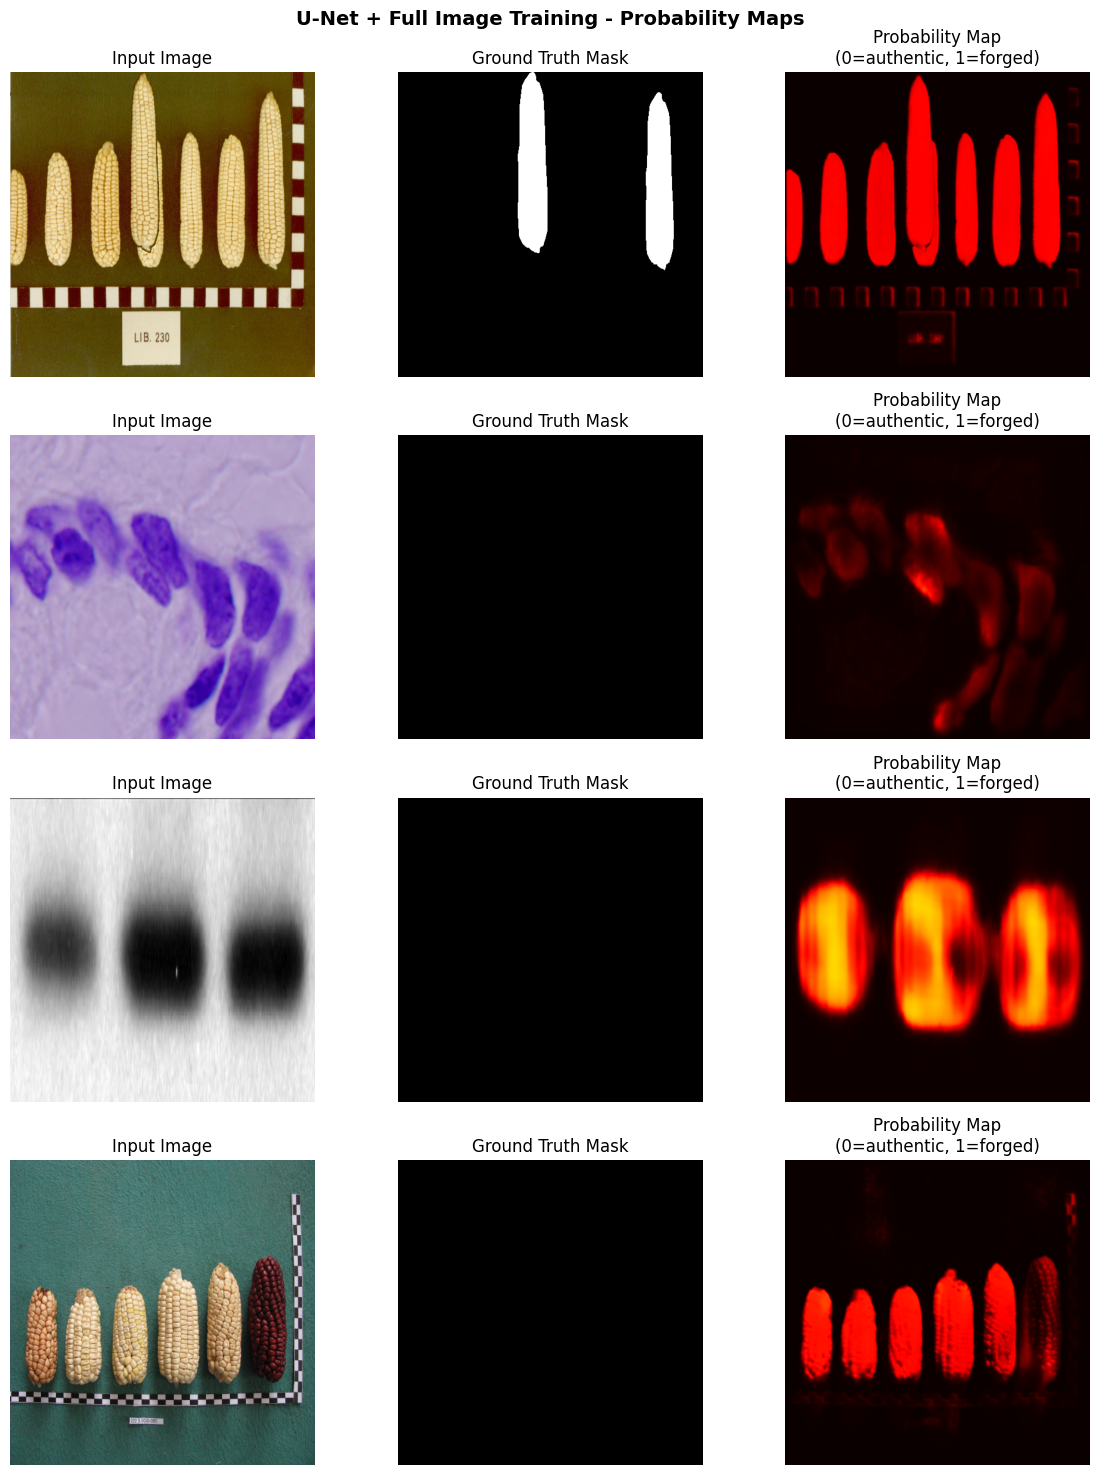

In [ ]:
# Ablation 3.1: Full Image (Baseline)
train_gen_full = SegmentationDataGenerator(
    train_df, BATCH_SIZE, TARGET_SIZE,
    get_augmentation('light'), shuffle=True, crop_strategy='full'
)

model_full = build_unet_scratch()
history_full = train_experiment(
    model_full, train_gen_full, val_gen,
    'unet_scratch_region_full',
    get_loss_function('bce_dice'),
    epochs=EPOCHS
)

# Visualize probability map output
fig = visualize_prediction_sample(model_full, val_gen, "U-Net + Full Image Training - Probability Maps")
plt.savefig(OUTPUT_DIR / 'unet_region_full_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


Training: unet_scratch_region_context
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - dice_coef: 0.0720 - iou_coef: 0.3343 - loss: 1.2282
Epoch 1: val_dice_coef improved from -inf to 0.06146, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_region_context.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 293s 607ms/step - dice_coef: 0.0720 - iou_coef: 0.3343 - loss: 1.2282 - val_dice_coef: 0.0615 - val_iou_coef: 0.1267 - val_loss: 1.1672 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - dice_coef: 0.0903 - iou_coef: 0.2749 - loss: 1.1546
Epoch 2: val_dice_coef improved from 0.06146 to 0.07354, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_region_context.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 263s 586ms/step - dice_coef: 0.0904 - iou_coef: 0.2749 - loss: 1.1546 - val_dice_coef: 0.0735 - val_iou_coef: 0.1501 - val_loss: 1.1721 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step 

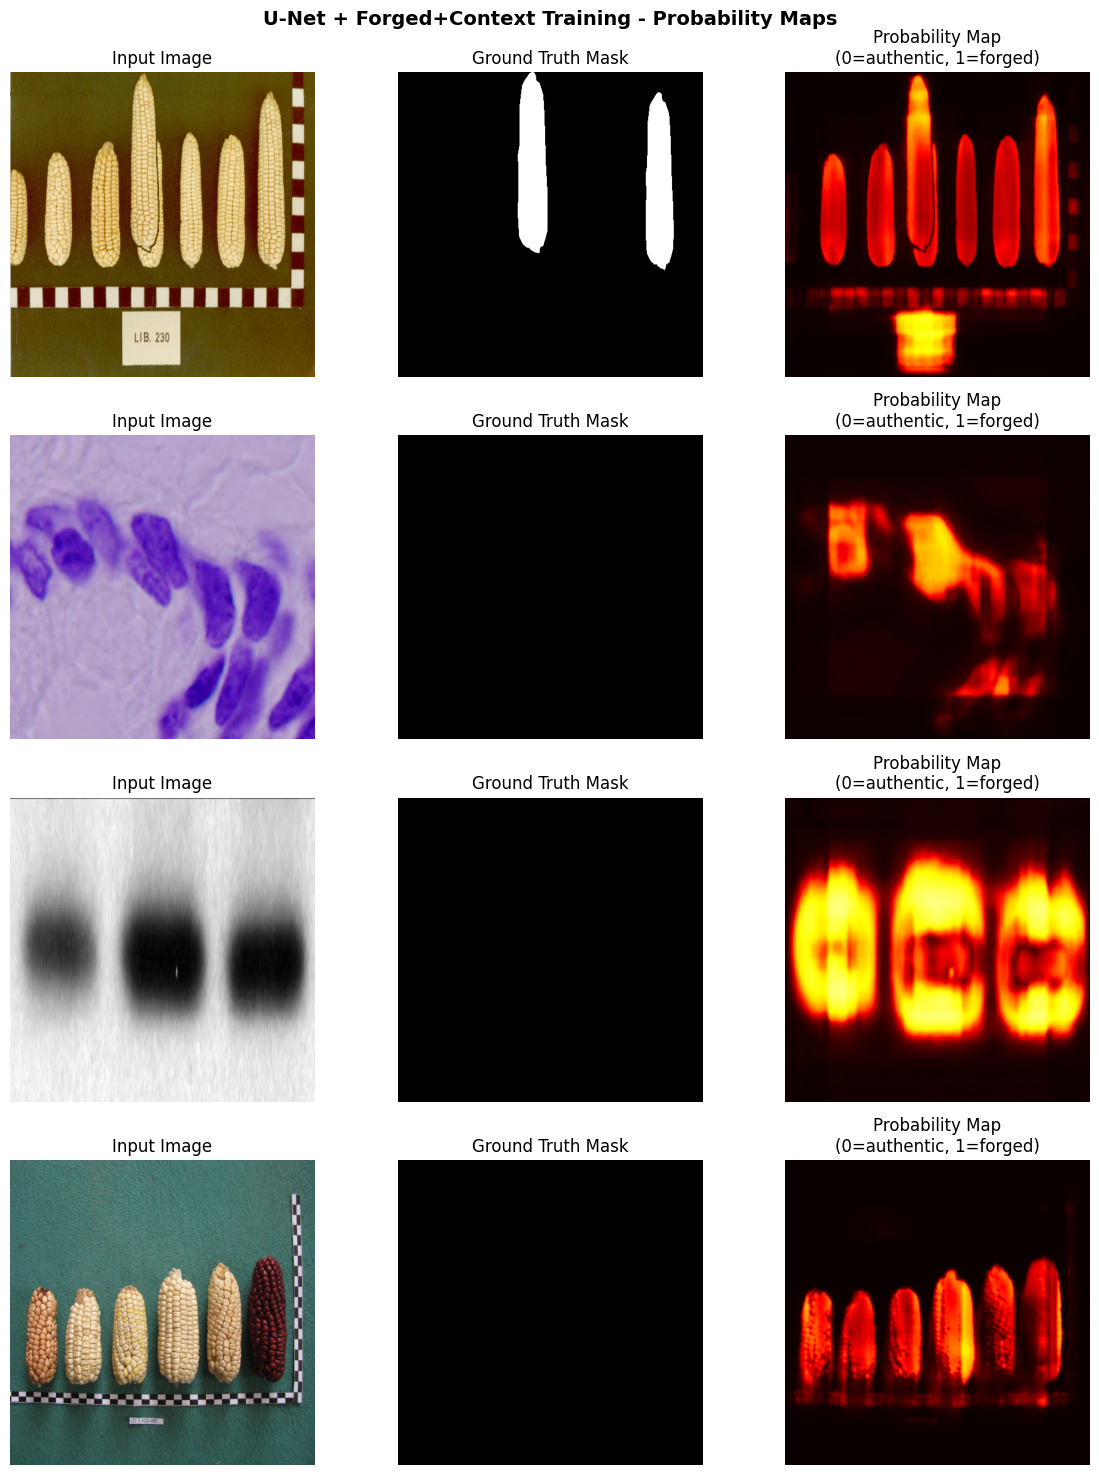

In [ ]:
# Ablation 3.2: Forged Region + Context (20% padding)
train_gen_context = SegmentationDataGenerator(
    train_df, BATCH_SIZE, TARGET_SIZE,
    get_augmentation('light'), shuffle=True, crop_strategy='forged_context'
)

model_context = build_unet_scratch()
history_context = train_experiment(
    model_context, train_gen_context, val_gen,
    'unet_scratch_region_context',
    get_loss_function('bce_dice'),
    epochs=EPOCHS
)

# Visualize probability map output
fig = visualize_prediction_sample(model_context, val_gen, "U-Net + Forged+Context Training - Probability Maps")
plt.savefig(OUTPUT_DIR / 'unet_region_context_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


Training: unet_scratch_region_tight
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef: 0.1161 - iou_coef: 0.2522 - loss: 1.2903
Epoch 1: val_dice_coef improved from -inf to 0.06656, saving model to /content/drive/MyDrive/DeepLearning_Project/models/unet_scratch_region_tight.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 1885s 4s/step - dice_coef: 0.1161 - iou_coef: 0.2524 - loss: 1.2902 - val_dice_coef: 0.0666 - val_iou_coef: 0.3504 - val_loss: 1.1949 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - dice_coef: 0.1124 - iou_coef: 0.3623 - loss: 1.2175
Epoch 2: val_dice_coef did not improve from 0.06656
449/449 ━━━━━━━━━━━━━━━━━━━━ 259s 577ms/step - dice_coef: 0.1124 - iou_coef: 0.3623 - loss: 1.2175 - val_dice_coef: 0.0632 - val_iou_coef: 0.3569 - val_loss: 1.1383 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - dice_coef: 0.1179 - iou_coef: 0.3227 - loss: 1.2160
Epoch 3: val_dice_coef did not improve from 0.06656
449/449 ━

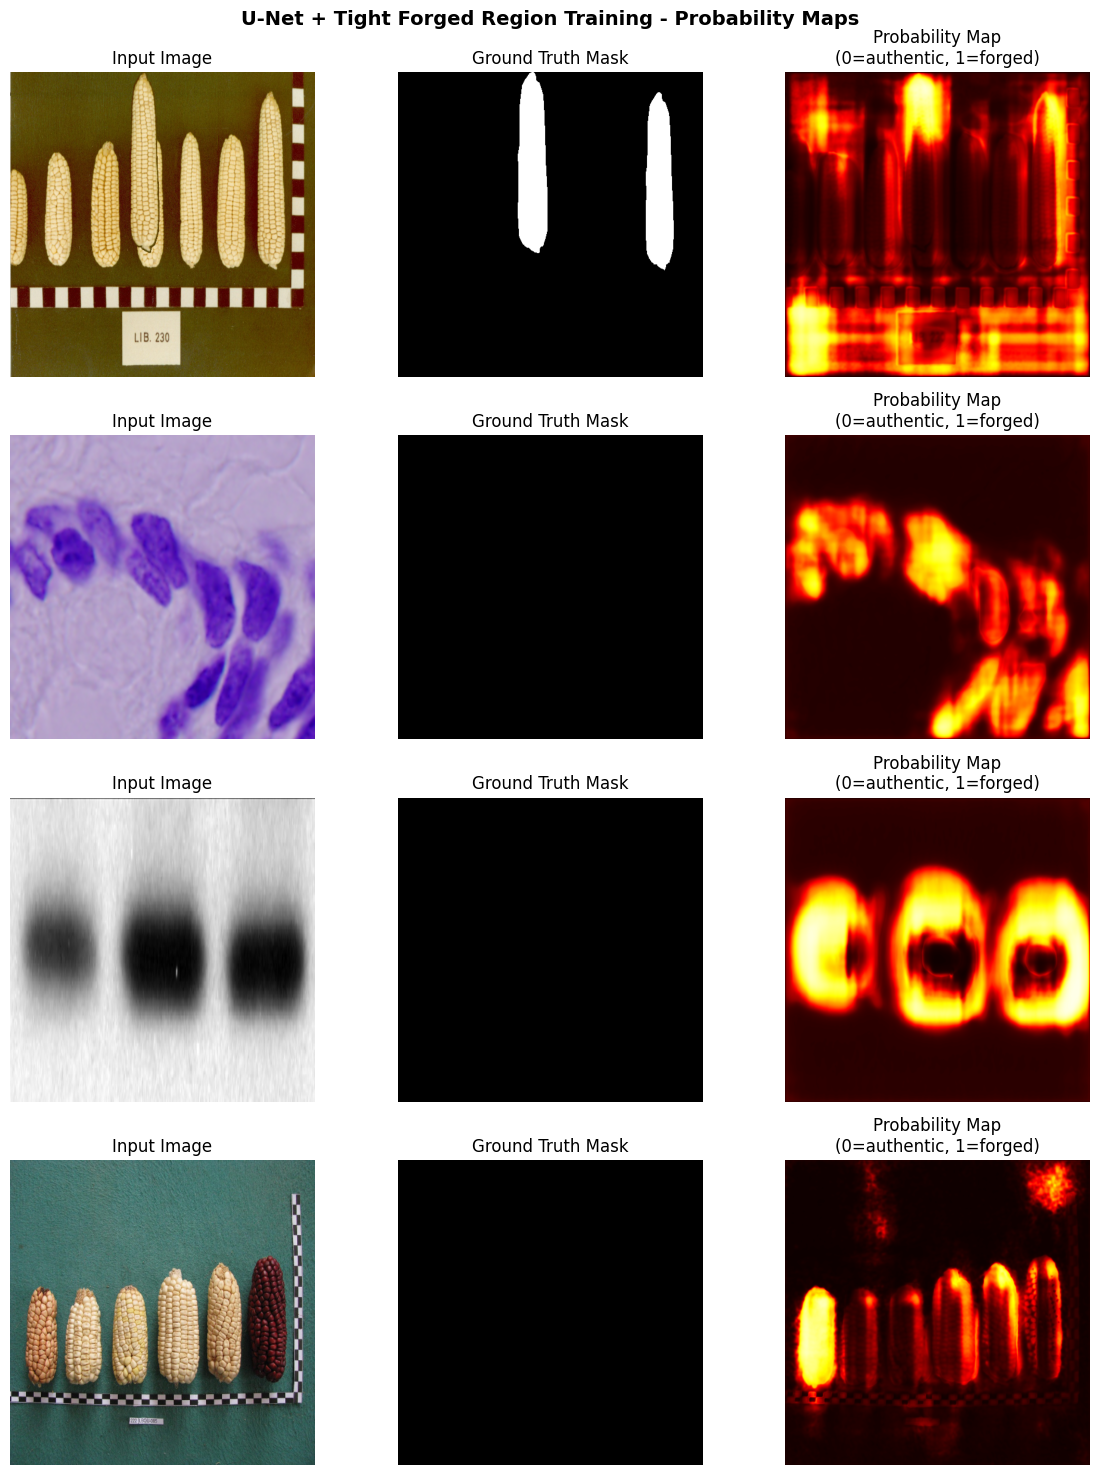

In [14]:
# Ablation 3.3: Forged Region Only (Tight Crop)
train_gen_tight = SegmentationDataGenerator(
    train_df, BATCH_SIZE, TARGET_SIZE,
    get_augmentation('light'), shuffle=True, crop_strategy='forged_tight'
)

model_tight = build_unet_scratch()
history_tight = train_experiment(
    model_tight, train_gen_tight, val_gen,
    'unet_scratch_region_tight',
    get_loss_function('bce_dice'),
    epochs=EPOCHS
)

# Visualize probability map output
fig = visualize_prediction_sample(model_tight, val_gen, "U-Net + Tight Forged Region Training - Probability Maps")
plt.savefig(OUTPUT_DIR / 'unet_region_tight_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Results Summary

In [15]:
# Load all training logs and create summary
def load_best_metrics(log_path):
    """Load best metrics from training log."""
    try:
        df = pd.read_csv(log_path)
        best_idx = df['val_dice_coef'].idxmax()
        return {
            'best_epoch': best_idx + 1,
            'val_dice': df.loc[best_idx, 'val_dice_coef'],
            'val_iou': df.loc[best_idx, 'val_iou_coef'],
            'val_loss': df.loc[best_idx, 'val_loss']
        }
    except:
        return None

# Collect results
experiments = [
    # Ablation 1: Loss Functions
    ('U-Net + BCE', 'unet_scratch_bce'),
    ('U-Net + Dice', 'unet_scratch_dice'),
    ('U-Net + BCE+Dice', 'unet_scratch_bce_dice'),
    # Ablation 2: Pretrained
    ('U-Net ResNet50', 'unet_resnet50_bce_dice'),
    # Ablation 3: Region-Focused Training
    ('U-Net + Full Image', 'unet_scratch_region_full'),
    ('U-Net + Forged+Context', 'unet_scratch_region_context'),
    ('U-Net + Forged Tight', 'unet_scratch_region_tight'),
]

results = []
for name, exp_name in experiments:
    log_path = OUTPUT_DIR / f'{exp_name}_log.csv'
    metrics = load_best_metrics(log_path)
    if metrics:
        results.append({
            'Experiment': name,
            'Best Epoch': metrics['best_epoch'],
            'Val Dice': f"{metrics['val_dice']:.4f}",
            'Val IoU': f"{metrics['val_iou']:.4f}",
            'Val Loss': f"{metrics['val_loss']:.4f}"
        })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("U-Net ABLATION STUDY RESULTS")
print("="*80)
print(results_df.to_string(index=False))


U-Net ABLATION STUDY RESULTS
            Experiment  Best Epoch Val Dice Val IoU Val Loss
           U-Net + BCE          20   0.0538  0.4638   0.1112
          U-Net + Dice          20   0.4638  0.4638   0.5362
      U-Net + BCE+Dice          18   0.1049  0.2004   1.0279
        U-Net ResNet50          17   0.2493  0.3053   0.9324
    U-Net + Full Image          20   0.1083  0.2034   1.0154
U-Net + Forged+Context          18   0.1040  0.1165   1.0359
  U-Net + Forged Tight           9   0.0971  0.1039   1.1590


In [16]:
# Save results summary
results_df.to_csv(OUTPUT_DIR / 'unet_ablation_results.csv', index=False)
print(f"\nResults saved to: {OUTPUT_DIR / 'unet_ablation_results.csv'}")


Results saved to: /content/drive/MyDrive/DeepLearning_Project/models/unet_ablation_results.csv


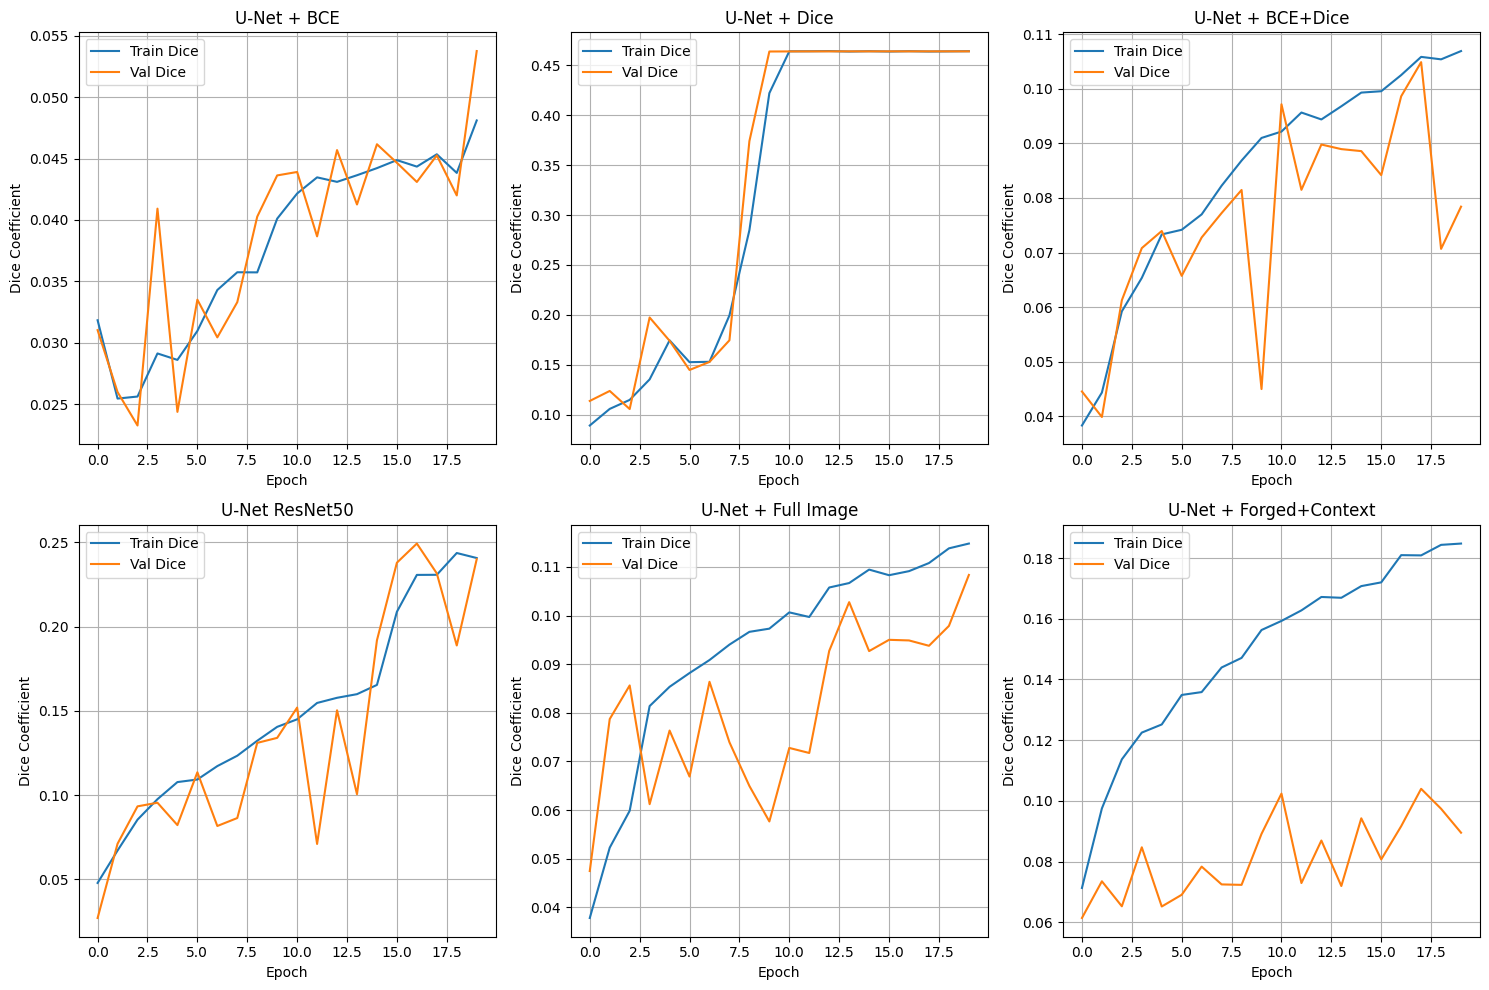

In [17]:
# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (name, exp_name) in enumerate(experiments):
    log_path = OUTPUT_DIR / f'{exp_name}_log.csv'
    try:
        df = pd.read_csv(log_path)
        ax = axes[idx // 3, idx % 3]
        ax.plot(df['dice_coef'], label='Train Dice')
        ax.plot(df['val_dice_coef'], label='Val Dice')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Dice Coefficient')
        ax.legend()
        ax.grid(True)
    except:
        pass

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'unet_training_curves.png', dpi=150)
plt.show()

## 11. Download Models & Results

Download the trained models and results for combining with other notebooks.

In [18]:
# List all output files
print("Output files:")
for f in OUTPUT_DIR.glob('*'):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name}: {size_mb:.2f} MB")

Output files:
  ablation_backbone_results.json: 0.00 MB
  threshold_analysis.png: 0.08 MB
  ablation_threshold_results.json: 0.00 MB
  ablation_training_size_results.json: 0.00 MB
  training_size_analysis.png: 0.07 MB
  unet_bce_predictions.png: 1.50 MB
  unet_scratch_bce_log.csv: 0.00 MB
  unet_scratch_bce.keras: 90.17 MB
  unet_scratch_dice_log.csv: 0.00 MB
  unet_dice_predictions.png: 1.25 MB
  unet_scratch_bce_dice_log.csv: 0.00 MB
  unet_scratch_dice.keras: 90.17 MB
  unet_scratch_bce_dice.keras: 90.17 MB
  unet_bce_dice_predictions.png: 1.54 MB
  unet_resnet50_bce_dice_log.csv: 0.00 MB
  unet_resnet50_bce_dice.keras: 373.62 MB
  unet_resnet50_predictions.png: 1.43 MB
  unet_region_full_predictions.png: 1.53 MB
  unet_scratch_region_context_log.csv: 0.00 MB
  unet_scratch_region_full_log.csv: 0.00 MB
  unet_scratch_region_full.keras: 90.17 MB
  unet_scratch_region_context.keras: 90.17 MB
  unet_region_context_predictions.png: 1.63 MB
  unet_scratch_region_tight.keras: 90.17 MB
  u